In [ ]:
!unzip PySESM.zip
!pip install torchmetrics
!mkdir figs_1
!mkdir figs_2
!mkdir figs_3
!mkdir figs_4

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal
from torchmetrics import MeanSquaredError, Accuracy, Precision, Recall, F1Score
from sklearn.model_selection import RandomizedSearchCV

from PySESM.models.SESM.SESM import SESM_Model
from PySESM.base_functions.Function import GaussianFunctions


## Definicion de covarianzas no diagnonales

In [ ]:

# Non-diagonal covariance
def generate_sigma_tensors():
    e0 = torch.tensor([1.0, 1.0], dtype=torch.float32)
    e0 = e0 / e0.norm()

    def generate_sigma(rotation_angle, scaling_factors):
        rotation_matrix = torch.tensor([[np.cos(rotation_angle), -np.sin(rotation_angle)],
                                       [np.sin(rotation_angle), np.cos(rotation_angle)]], dtype=torch.float32)
        e = torch.mm(rotation_matrix, e0.unsqueeze(1))
        E = torch.cat((e0.unsqueeze(1), e), dim=1)
        D = torch.diag(torch.tensor(scaling_factors, dtype=torch.float32))
        return torch.mm(torch.mm(E, D), E.t())

    sigma1 = generate_sigma(np.pi/4, [0.4, 0.1])
    sigma2 = generate_sigma(np.pi/4, [0.05, 0.5])
    sigma3 = generate_sigma(np.pi/4, [0.2, 0.5])

    return sigma1, sigma2, sigma3


In [ ]:
sigma1, sigma2, sigma3 = generate_sigma_tensors()

## Definicion de varianzas diagonales

In [ ]:
sigma1_d = 0.15 * torch.eye(2)
sigma2_d = 0.2 * torch.eye(2)
sigma3_d = 0.3 *torch.eye(2)

## Crear Gaussianas

In [ ]:
def custom_initializer(mean, std_dev, shape, a=0, b=1):
    # Crea una distribución gaussiana con los valores de media y desviación estándar
    distribution = torch.normal(mean=torch.full(shape, mean, dtype=torch.float32), std=torch.full(shape, std_dev, dtype=torch.float32))

    # Estandariza los valores generados en el rango a, b
    std_distribution = (distribution - distribution.mean()) / distribution.std()
    # scaled_distribution = a + (std_distribution - std_distribution.min()) * (b - a) / (std_distribution.max() - std_distribution.min())

    return std_distribution

mean = 0.0
std_dev = 0.1
a = -1
b = 1
shape = (2,)

In [ ]:
def generate_mesh_and_z(sigma1, sigma2, sigma3):
    N_points = 50
    xl = -2
    xr = 2

    x = np.linspace(xl, xr, N_points+1)
    xx, yy = np.meshgrid(x, x)

    X = torch.tensor(np.column_stack([xx.ravel(), yy.ravel()]), dtype=torch.float32)

    mu1 = custom_initializer(mean, std_dev, shape, a, b)
    mu2 = custom_initializer(mean, std_dev, shape, a, b)
    mu3 = custom_initializer(mean, std_dev, shape, a, b)

    '''mu1 = torch.tensor([1, 1], dtype=torch.float32)
    mu2 = torch.tensor([1, -1], dtype=torch.float32)
    mu3 = torch.tensor([-1, -1], dtype=torch.float32)'''

    print("Myus: ", mu1, mu2, mu3)

    z1 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu1.numpy(), sigma1.numpy()), dtype=torch.float32)
    z2 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu2.numpy(), sigma2.numpy()), dtype=torch.float32)
    z3 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu3.numpy(), sigma3.numpy()), dtype=torch.float32)

    zz = (z1 + z2 + z3).reshape(xx.shape)

    return xx, yy, zz




## Covarianza de gaussianas del experimento:
  - 3 Diagonales
  - 2 Diagonales, 1 no diagonal
  - 1 diagonal, 2 no diagonales
  - 3 no diagonales

In [ ]:

def run_experiment(_x, _y, _z, m_epochs, dict_epochs, h_epochs,expe, iter, debug=True):
  x_values = _x.ravel()
  y_values = _y.ravel()
  z_values = _z.ravel()

  n_samples = 500 # pueden aumentarse
  n_features = 2
  l_functions =  10 # bajarlas a <10
  total_points = len(x_values)

  min_separation = 1 # se puede reducir

  selected_indexes = []
  #Generate a uniform sampling
  while len(selected_indexes) < n_samples:

      random_index = np.random.randint(total_points)

      if all(abs(random_index - existing_index) >= min_separation for existing_index in selected_indexes):
          selected_indexes.append(random_index)

  sampled_indices = selected_indexes

  sampled_x = torch.tensor(x_values[sampled_indices], dtype=torch.float32)
  sampled_y = torch.tensor(y_values[sampled_indices], dtype=torch.float32)

  X = torch.stack((sampled_x, sampled_y), dim=1)
  y = z_values[sampled_indices].clone().detach().to(dtype=torch.float32)

  gaussian_function = GaussianFunctions(n_features= n_features, n_functions = l_functions)
  model = SESM_Model(
    n_samples=n_samples,
    n_features=n_features,
    n_functions=l_functions,
    psi=gaussian_function.gaussian
    )

  model_epochs = m_epochs
  ista_epochs = h_epochs
  dictionary_epochs = dict_epochs

  # reajustar estos parametros
  ista_alpha = 0.0125
  ista_lambd = 0.001

  dictionary_alpha = 0.0125

  model.fit(
      X=X,
      y=y,
      model_epochs=model_epochs,
      ista_epochs=ista_epochs,
      ista_alpha=ista_alpha,
      ista_lambd=ista_lambd,
      dictionary_epochs=dictionary_epochs,
      dictionary_alpha=dictionary_alpha
      )


  x_tensor = torch.tensor(x_values)
  y_tensor = torch.tensor(y_values)
  XY = torch.cat((x_tensor.unsqueeze(1), y_tensor.unsqueeze(1)), dim=1)

  Z = model.predict(XY)

  time = model.time/60

  #Init MSE metric
  mse = MeanSquaredError()
  # Compute MSE
  mse(Z.clone().detach(), z_values)
  mse_value = mse.compute()

  print(f"Losses lenght: {len(model.dictionary_layer.losses)}")

  if debug:
    fig = plt.figure(figsize=(6, 6))

    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(x_values, y_values, z_values,c=z_values)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title('Original Function')


    ax2 = fig.add_subplot(222, projection='3d')
    ax2.scatter(x_values, y_values, Z.clone().detach(), c=Z.clone().detach())
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.set_title('Surrogate Model')
    ax2.set_zlim(0)


    #Show the plot
    fname = f"figs_{expe}/{iter}.png"
    plt.savefig(fname)
    #plt.show()
    plt.clf()

    plt.plot(model.losses)
    plt.ylabel('Loss')
    plt.xlabel('Iteration')
    fname = f"figs_{expe}/{iter}-loss.png"
    plt.savefig(fname)
    print(f"Current h {model.ista_layer.h}")
  return time, mse_value

In [ ]:
import csv

def save_results(data, expe):
  # Calcular el promedio y la desviación estándar para time y mse
  times = [item[1] for item in data]
  mse_values = [item[2] for item in data]

  average_time = np.mean(times)
  std_time = np.std(times)
  average_mse = np.mean(mse_values)
  std_mse = np.std(mse_values)

  # Guardar los datos en un archivo CSV
  with open(f"resultados_{expe}.csv", mode="w", newline="") as file:
      writer = csv.writer(file)
      writer.writerow(["iter", "Tiempo (min)", "mse"])
      writer.writerows(data)
      writer.writerow(["Promedio", average_time, average_mse])
      writer.writerow(["Desviación Estándar", std_time, std_mse])


In [ ]:
# 3 diag
xx, yy, zz = generate_mesh_and_z(sigma1_d, sigma2_d, sigma3_d)

# 2 diag, 1 no diag
xx_1, yy_1, zz_1 = generate_mesh_and_z(sigma1_d, sigma2_d, sigma3)

# 1 diag, 2 no diag
xx_2, yy_2, zz_2 = generate_mesh_and_z(sigma1_d, sigma2, sigma3)
# 3 no diag
xx_3, yy_3, zz_3 = generate_mesh_and_z(sigma1, sigma2, sigma3)

Myus:  tensor([ 0.7071, -0.7071]) tensor([-0.7071,  0.7071]) tensor([ 0.7071, -0.7071])
Myus:  tensor([-0.7071,  0.7071]) tensor([ 0.7071, -0.7071]) tensor([ 0.7071, -0.7071])
Myus:  tensor([ 0.7071, -0.7071]) tensor([ 0.7071, -0.7071]) tensor([-0.7071,  0.7071])
Myus:  tensor([ 0.7071, -0.7071]) tensor([-0.7071,  0.7071]) tensor([ 0.7071, -0.7071])


In [ ]:

fig = go.Figure(data=[go.Surface(z=zz_3.numpy(), x=xx_3, y=yy_3)])
fig.update_layout(scene=dict(aspectmode='data'))
fig.update_layout(scene=dict(camera=dict(eye=dict(x=2, y=2, z=1))))

fig.show()

In [ ]:
from google.colab import files

N_iter        = 1
m_epochs      = 20
dict_epochs   = 60
h_epochs      = 100

# Nomenclatura de experimentos

<Set de hiperparámetros>. <Set de datos (conjunto de gaussianas)>.<Número de repetición del experimento>


## Set de Hiperparámetros
|  Hiperparámetro | Exp 1.x.x     | Exp 2.x.x     | Exp 3.x.x     |
|-----------------|---------------|---------------|---------------|
| n_samples       | 50            | 100           | 500           |
| n_features      | 2             | 2             | 2             |
| l_functions     | 20            | 6             | 10            |
| ista_alpha      | 0.06          | 0.0125        | 0.0125        |
| ista_lambd      | 0.005         | 0.001         | 0.001         |
| dictionary_alpha| 0.06          | 0.0125        | 0.0125        |
| m_epochs        | 25            | 500           | 300           |
| dict_epochs     | 800           | 20            | 60            |
| h_epochs        | 1000          | 50            | 100           |


### Set de datos

|     Set      | Exp 1.x.x     | Exp 2.x.x     | Exp 3.x.x     |
|-----------------|---------------|---------------|---------------|
| Gaussianas 1    | Exp 1.1.x     | Exp 2.1.x     | Exp 3.1.x     |
| Gaussianas 2    | Exp 1.2.x     | Exp 2.2.x     | Exp 3.2.x     |
| Gaussianas 3    | Exp 1.3.x     | Exp 2.3.x     | Exp 3.3.x     |
| Gaussianas 4    | Exp 1.4.x     | Exp 2.4.x     | Exp 3.4.x     |


Training model:   5%|▌         | 1/20 [00:00<00:05,  3.18it/s]

Epoch 1 Loss: 2.0209672451019287



Training model:  10%|█         | 2/20 [00:00<00:05,  3.39it/s]

Epoch 2 Loss: 0.39148491621017456



Training model:  15%|█▌        | 3/20 [00:00<00:04,  3.49it/s]

...

Training model:  95%|█████████▌| 19/20 [00:08<00:00,  1.66it/s]

Epoch 19 Loss: 0.011133692227303982



Training model: 100%|██████████| 20/20 [00:09<00:00,  2.08it/s]

Epoch 20 Loss: 0.010517467744648457

Losses lenght: 1200


Current h Parameter containing:
tensor([-0.0586,  0.7078,  0.1850,  0.2548,  0.0123,  0.1300, -0.0042,  0.5128,
        -0.1115,  0.2369], requires_grad=True)


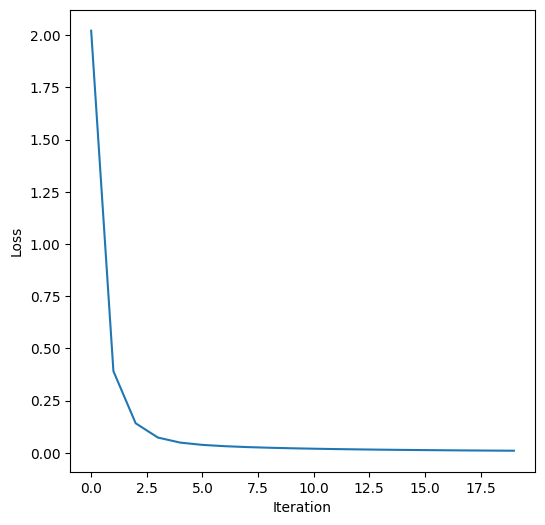

In [ ]:

data = []
for i in range(N_iter):
  time, mse = run_experiment(xx,yy,zz,
                 m_epochs=m_epochs,
                 dict_epochs=dict_epochs,
                 h_epochs=h_epochs, expe=1, iter=i)
  data.append((i, time, mse.item()))

save_results(data=data, expe=1)

In [ ]:
files.download('resultados_1.csv')
!zip -r figs_1.zip figs_1/
files.download('figs_1.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_1/ (stored 0%)
  adding: figs_1/0-loss.png (deflated 15%)
  adding: figs_1/0.png (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training model:   5%|▌         | 1/20 [00:00<00:05,  3.18it/s]

Epoch 1 Loss: 2.6224334239959717



Training model:  10%|█         | 2/20 [00:00<00:08,  2.14it/s]

Epoch 2 Loss: 0.4541345238685608



Training model:  15%|█▌        | 3/20 [00:01<00:07,  2.16it/s]

...

Training model:  95%|█████████▌| 19/20 [00:11<00:00,  1.13it/s]

Epoch 19 Loss: 0.0226377435028553



Training model: 100%|██████████| 20/20 [00:12<00:00,  1.55it/s]

Epoch 20 Loss: 0.02092774584889412

Losses lenght: 1200


Current h Parameter containing:
tensor([ 1.2146e-01, -2.9455e-02,  5.7655e-01, -1.3499e-01, -2.5706e-04,
        -1.2041e-01,  2.8198e-02,  6.5099e-01,  4.3875e-01,  2.8524e-02],
       requires_grad=True)


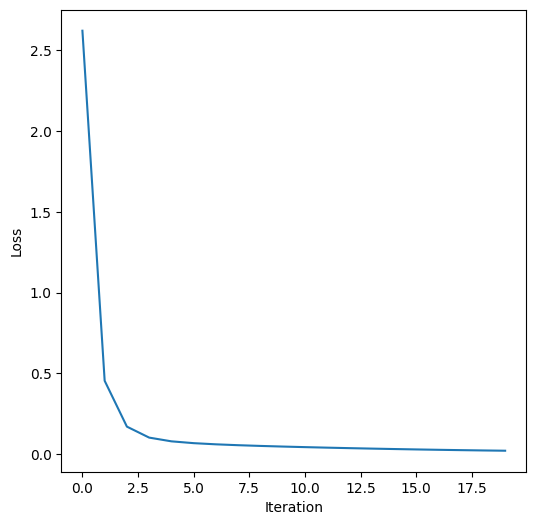

In [ ]:
data_1 = []

for i in range(N_iter):
  time, mse = run_experiment(xx_1,yy_1,zz_1,
                 m_epochs=m_epochs,
                 dict_epochs=dict_epochs,
                 h_epochs=h_epochs, expe=2, iter=i)
  data_1.append((i, time, mse.item()))

save_results(data=data_1, expe=2)

In [ ]:
files.download('resultados_2.csv')
!zip -r figs_2.zip figs_2/
files.download('figs_2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_2/ (stored 0%)
  adding: figs_2/0-loss.png (deflated 15%)
  adding: figs_2/0.png (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training model:   5%|▌         | 1/20 [00:00<00:03,  5.88it/s]

Epoch 1 Loss: 2.5960283279418945



Training model:  10%|█         | 2/20 [00:00<00:04,  4.41it/s]

Epoch 2 Loss: 0.3186182379722595



Training model:  15%|█▌        | 3/20 [00:00<00:04,  4.10it/s]

...

Training model:  95%|█████████▌| 19/20 [00:04<00:00,  3.77it/s]

Epoch 19 Loss: 0.027490513399243355



Training model: 100%|██████████| 20/20 [00:05<00:00,  3.82it/s]

Epoch 20 Loss: 0.02662714570760727

Losses lenght: 1200


Current h Parameter containing:
tensor([ 0.3723,  0.3718,  0.1112,  1.3867,  0.5321, -0.3105, -0.1375,  0.1112,
         0.4271,  0.1317], requires_grad=True)


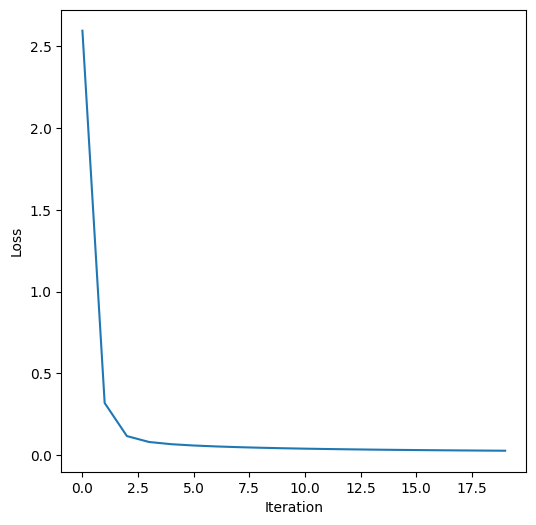

In [ ]:
data_2 = []
for i in range(N_iter):
  time, mse = run_experiment(xx_2,yy_2,zz_2,
                 m_epochs=m_epochs,
                 dict_epochs=dict_epochs,
                 h_epochs=h_epochs, expe=3, iter=i)
  data_2.append((i, time, mse.item()))

save_results(data=data_2, expe=3)

In [ ]:
files.download('resultados_3.csv')
!zip -r figs_3.zip figs_3/
files.download('figs_3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_3/ (stored 0%)
  adding: figs_3/0-loss.png (deflated 15%)
  adding: figs_3/0.png (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training model:   5%|▌         | 1/20 [00:00<00:03,  5.91it/s]

Epoch 1 Loss: 2.18308162689209



Training model:  10%|█         | 2/20 [00:00<00:04,  4.17it/s]

Epoch 2 Loss: 0.41799986362457275



Training model:  15%|█▌        | 3/20 [00:00<00:04,  4.02it/s]

...

Training model:  95%|█████████▌| 19/20 [00:05<00:00,  2.76it/s]

Epoch 19 Loss: 0.05299035459756851



Training model: 100%|██████████| 20/20 [00:06<00:00,  3.28it/s]

Epoch 20 Loss: 0.052188217639923096

Losses lenght: 1200


Current h Parameter containing:
tensor([ 0.1158, -0.0147,  0.1586,  0.4721,  0.3372,  0.3299, -0.0248,  0.1276,
         0.3439, -0.0629], requires_grad=True)


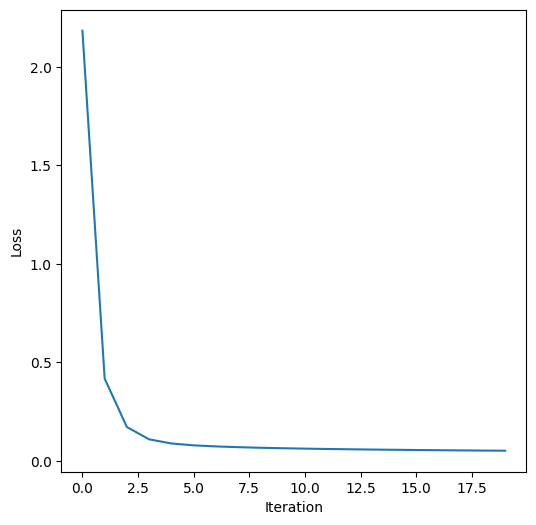

In [ ]:
data_3 = []
for i in range(N_iter):
  time, mse = run_experiment(xx_3,yy_3,zz_3,
                 m_epochs=m_epochs,
                 dict_epochs=dict_epochs,
                 h_epochs=h_epochs, expe=4, iter=i)
  data_3.append((i, time, mse.item()))

save_results(data=data_3, expe=4)

In [ ]:

files.download('resultados_4.csv')
!zip -r figs_4.zip figs_4/
files.download('figs_4.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: figs_4/ (stored 0%)
  adding: figs_4/0-loss.png (deflated 15%)
  adding: figs_4/0.png (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>